In [1]:
# Cell 1: Setup and Imports
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import pickle
import warnings
warnings.filterwarnings('ignore')



In [6]:
# Set paths
PROJECT_ROOT = os.path.expanduser('/scratch/user/u.st336499/ML_Project/disaster_response_project')
DATA_RAW = os.path.join(PROJECT_ROOT, 'data/raw')
DATA_PROCESSED = os.path.join(PROJECT_ROOT, 'data/processed')
FIGURES_DIR = os.path.join(PROJECT_ROOT, 'figures')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')
REPORTS_DIR = os.path.join(PROJECT_ROOT, 'reports')



In [7]:
# Create directories if they don't exist
for directory in [DATA_PROCESSED, FIGURES_DIR, MODELS_DIR, REPORTS_DIR]:
    os.makedirs(directory, exist_ok=True)



In [8]:
# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("DISASTER RESPONSE PROJECT - PHASE 1")
print("Real Data Analysis and Baseline Model")
print("="*70)
print(f"\n Project Root: {PROJECT_ROOT}")
print(f" All directories created")
print(f" Libraries imported successfully")
print(f"\nPandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

DISASTER RESPONSE PROJECT - PHASE 1
Real Data Analysis and Baseline Model

 Project Root: /scratch/user/u.st336499/ML_Project/disaster_response_project
 All directories created
 Libraries imported successfully

Pandas version: 2.0.3
NumPy version: 1.24.3


In [9]:
# Cell 2: Load and Inspect Data
print("="*70)
print("STEP 1: LOADING DATASET")
print("="*70)

# Load the data (handle BOM character)
df = pd.read_csv(os.path.join(DATA_RAW, 'tweets.csv'), encoding='utf-8-sig')

print(f"\n Dataset loaded successfully!")
print(f"   Total tweets: {len(df):,}")
print(f"   Columns: {list(df.columns)}")

# Basic info
print(f"\n Dataset Info:")
print(df.info())

print(f"\n First 5 rows:")
print(df.head())

print(f"\n Target Distribution:")
print(df['target'].value_counts())
print(f"\n   Disaster tweets (1): {(df['target']==1).sum():,} ({(df['target']==1).sum()/len(df)*100:.1f}%)")
print(f"   Non-disaster tweets (0): {(df['target']==0).sum():,} ({(df['target']==0).sum()/len(df)*100:.1f}%)")

print(f"\n Missing Values:")
print(df.isnull().sum())

print(f"\n Data loaded and inspected!")

STEP 1: LOADING DATASET

 Dataset loaded successfully!
   Total tweets: 11,370
   Columns: ['id', 'keyword', 'location', 'text', 'target']

 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11370 entries, 0 to 11369
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        11370 non-null  int64 
 1   keyword   11370 non-null  object
 2   location  7952 non-null   object
 3   text      11370 non-null  object
 4   target    11370 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 444.3+ KB
None

 First 5 rows:
   id keyword        location  \
0   0  ablaze             NaN   
1   1  ablaze             NaN   
2   2  ablaze   New York City   
3   3  ablaze  Morgantown, WV   
4   4  ablaze             NaN   

                                                text  target  
0  Communal violence in Bhainsa, Telangana. "Ston...       1  
1  Telangana: Section 144 has been imposed in Bha...       1  
2  Arsonis

In [11]:
#  Data Preprocessing

print("STEP 2: DATA PREPROCESSING")


def clean_tweet(text):
    """Clean and preprocess tweet text"""
    if pd.isna(text):
        return ""
    
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove user mentions
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtag symbol but keep the text
    text = re.sub(r'#', '', text)
    
    # Remove special characters and digits (keep letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

# Apply cleaning
print("\n Cleaning tweets...")
df['cleaned_text'] = df['text'].apply(clean_tweet)

# Remove empty tweets
df = df[df['cleaned_text'].str.len() > 0].reset_index(drop=True)

# Add text length feature
df['text_length'] = df['cleaned_text'].str.len()
df['word_count'] = df['cleaned_text'].str.split().str.len()

print(f" Tweets cleaned!")
print(f"   Remaining tweets: {len(df):,}")
print(f"   Average length: {df['text_length'].mean():.1f} characters")
print(f"   Average words: {df['word_count'].mean():.1f} words")

# Show examples
print(f"\n Example Cleaned Tweets:")
for idx in df.sample(3).index:
    print(f"\n   Original: {df.loc[idx, 'text'][:80]}...")
    print(f"   Cleaned:  {df.loc[idx, 'cleaned_text'][:80]}...")
    print(f"   Target:   {df.loc[idx, 'target']} ({'Disaster' if df.loc[idx, 'target']==1 else 'Not Disaster'})")

STEP 2: DATA PREPROCESSING

 Cleaning tweets...
 Tweets cleaned!
   Remaining tweets: 11,364
   Average length: 90.4 characters
   Average words: 16.2 words

 Example Cleaned Tweets:

   Original: #ThisIsNotJournalism The Coalition Govt Government buried climate risk action pl...
   Cleaned:  thisisnotjournalism the coalition govt government buried climate risk action pla...
   Target:   0 (Not Disaster)

   Original: [CLOCOLAN] – Two killed when bakkie and car collide. https://t.co/A3zZTtIu2Z …...
   Cleaned:  clocolan two killed when bakkie and car collide...
   Target:   1 (Disaster)

   Original: 61yo man is first fatality in mystery virus outbreak in #China leads; disease sp...
   Cleaned:  yo man is first fatality in mystery virus outbreak in china leads disease spread...
   Target:   1 (Disaster)


In [12]:
#  Train-Test Split
from sklearn.model_selection import train_test_split

print("="*70)
print("STEP 3: TRAIN-VALIDATION-TEST SPLIT")
print("="*70)

# First split: separate test set (15%)
train_val, test = train_test_split(
    df, 
    test_size=0.15, 
    random_state=42,
    stratify=df['target']
)

# Second split: separate validation from training (15% of remaining = ~12.75% of total)
train, val = train_test_split(
    train_val,
    test_size=0.15,
    random_state=42,
    stratify=train_val['target']
)

print(f"\n Data Split:")
print(f"   Training:   {len(train):,} tweets ({len(train)/len(df)*100:.1f}%)")
print(f"   Validation: {len(val):,} tweets ({len(val)/len(df)*100:.1f}%)")
print(f"   Test:       {len(test):,} tweets ({len(test)/len(df)*100:.1f}%)")

print(f"\n Target Distribution in Each Split:")
print(f"   Train - Disaster: {(train['target']==1).sum():,} | Non-disaster: {(train['target']==0).sum():,}")
print(f"   Val   - Disaster: {(val['target']==1).sum():,} | Non-disaster: {(val['target']==0).sum():,}")
print(f"   Test  - Disaster: {(test['target']==1).sum():,} | Non-disaster: {(test['target']==0).sum():,}")

# Save processed data
train.to_csv(os.path.join(DATA_PROCESSED, 'train.csv'), index=False)
val.to_csv(os.path.join(DATA_PROCESSED, 'val.csv'), index=False)
test.to_csv(os.path.join(DATA_PROCESSED, 'test.csv'), index=False)

print(f"\n Data saved to: {DATA_PROCESSED}/")
print(f"   - train.csv")
print(f"   - val.csv")
print(f"   - test.csv")

STEP 3: TRAIN-VALIDATION-TEST SPLIT

 Data Split:
   Training:   8,210 tweets (72.2%)
   Validation: 1,449 tweets (12.8%)
   Test:       1,705 tweets (15.0%)

 Target Distribution in Each Split:
   Train - Disaster: 1,527 | Non-disaster: 6,683
   Val   - Disaster: 270 | Non-disaster: 1,179
   Test  - Disaster: 317 | Non-disaster: 1,388

 Data saved to: /scratch/user/u.st336499/ML_Project/disaster_response_project/data/processed/
   - train.csv
   - val.csv
   - test.csv


In [13]:
# EDA - Statistics
print("STEP 4: EXPLORATORY DATA ANALYSIS")

print("\n DATASET STATISTICS")
# Overall statistics
print(f"\nTotal Tweets: {len(df):,}")
print(f"Disaster Tweets: {(df['target']==1).sum():,} ({(df['target']==1).sum()/len(df)*100:.1f}%)")
print(f"Non-Disaster Tweets: {(df['target']==0).sum():,} ({(df['target']==0).sum()/len(df)*100:.1f}%)")

print(f"\n Text Length Statistics:")
print(f"   Mean: {df['text_length'].mean():.1f} characters")
print(f"   Median: {df['text_length'].median():.1f} characters")
print(f"   Min: {df['text_length'].min()} characters")
print(f"   Max: {df['text_length'].max()} characters")

print(f"\n Word Count Statistics:")
print(f"   Mean: {df['word_count'].mean():.1f} words")
print(f"   Median: {df['word_count'].median():.1f} words")
print(f"   Min: {df['word_count'].min()} words")
print(f"   Max: {df['word_count'].max()} words")

# Top keywords
print(f"\n Top 10 Keywords:")
top_keywords = df['keyword'].value_counts().head(10)
for keyword, count in top_keywords.items():
    print(f"   {keyword:20s}: {count:,} tweets")

# Text length by target
print(f"\n Text Length by Category:")
disaster_length = df[df['target']==1]['text_length'].mean()
non_disaster_length = df[df['target']==0]['text_length'].mean()
print(f"   Disaster tweets: {disaster_length:.1f} characters")
print(f"   Non-disaster tweets: {non_disaster_length:.1f} characters")

STEP 4: EXPLORATORY DATA ANALYSIS

 DATASET STATISTICS

Total Tweets: 11,364
Disaster Tweets: 2,114 (18.6%)
Non-Disaster Tweets: 9,250 (81.4%)

 Text Length Statistics:
   Mean: 90.4 characters
   Median: 100.0 characters
   Min: 4 characters
   Max: 139 characters

 Word Count Statistics:
   Mean: 16.2 words
   Median: 17.0 words
   Min: 1 words
   Max: 31 words

 Top 10 Keywords:
   thunderstorm        : 93 tweets
   flattened           : 88 tweets
   mass%20murder       : 86 tweets
   stretcher           : 86 tweets
   drown               : 83 tweets
   sirens              : 83 tweets
   drowning            : 83 tweets
   engulfed            : 82 tweets
   fear                : 80 tweets
   obliterate          : 80 tweets

 Text Length by Category:
   Disaster tweets: 94.7 characters
   Non-disaster tweets: 89.4 characters



 Creating Visualizations...
 Saved: 1_target_distribution.png


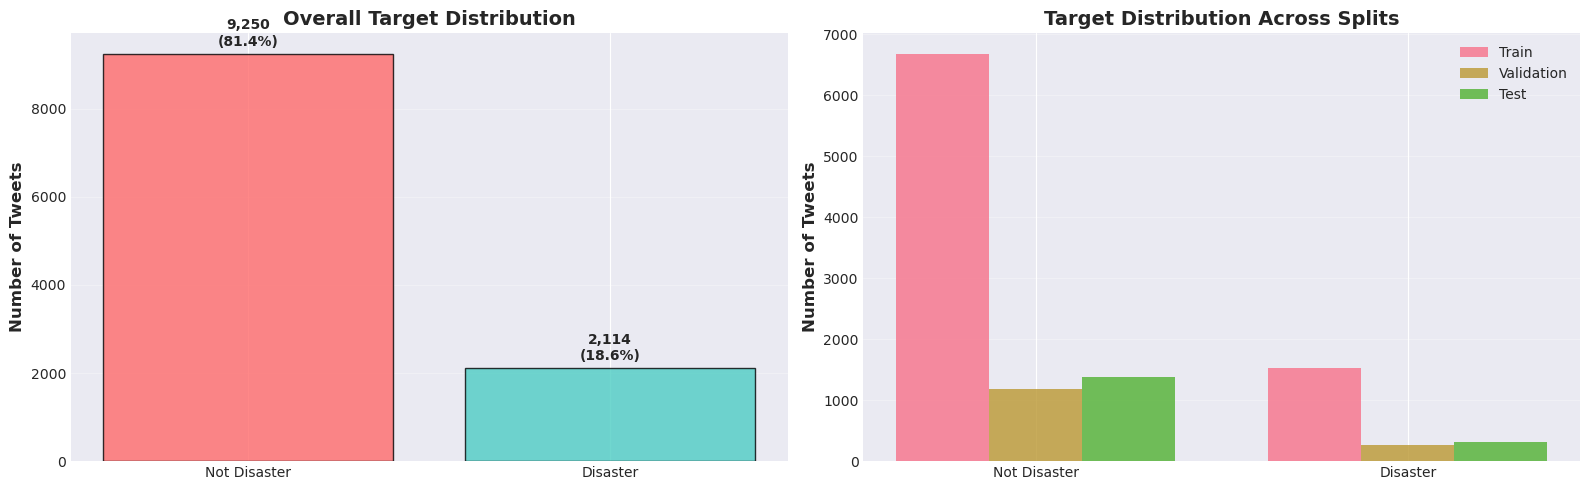

In [15]:
#  EDA - Visualizations Part 1 (Target Distribution)
print("\n Creating Visualizations...")

# Figure 1: Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall distribution
target_counts = df['target'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']
axes[0].bar(['Not Disaster', 'Disaster'], 
           [target_counts[0], target_counts[1]], 
           color=colors, alpha=0.8, edgecolor='black')
axes[0].set_ylabel('Number of Tweets', fontsize=12, fontweight='bold')
axes[0].set_title('Overall Target Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add percentages on bars
for i, (label, count) in enumerate(zip(['Not Disaster', 'Disaster'], [target_counts[0], target_counts[1]])):
    percentage = count / len(df) * 100
    axes[0].text(i, count + len(df)*0.01, 
                f'{count:,}\n({percentage:.1f}%)', 
                ha='center', va='bottom', fontweight='bold')

# Distribution across splits
split_data = pd.DataFrame({
    'Train': train['target'].value_counts(),
    'Validation': val['target'].value_counts(),
    'Test': test['target'].value_counts()
})

x = np.arange(2)
width = 0.25
axes[1].bar(x - width, [split_data.loc[0, 'Train'], split_data.loc[1, 'Train']], 
           width, label='Train', alpha=0.8)
axes[1].bar(x, [split_data.loc[0, 'Validation'], split_data.loc[1, 'Validation']], 
           width, label='Validation', alpha=0.8)
axes[1].bar(x + width, [split_data.loc[0, 'Test'], split_data.loc[1, 'Test']], 
           width, label='Test', alpha=0.8)

axes[1].set_ylabel('Number of Tweets', fontsize=12, fontweight='bold')
axes[1].set_title('Target Distribution Across Splits', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Not Disaster', 'Disaster'])
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '1_target_distribution.png'), dpi=300, bbox_inches='tight')
print(f" Saved: 1_target_distribution.png")
plt.show()

 Saved: 2_text_length_analysis.png


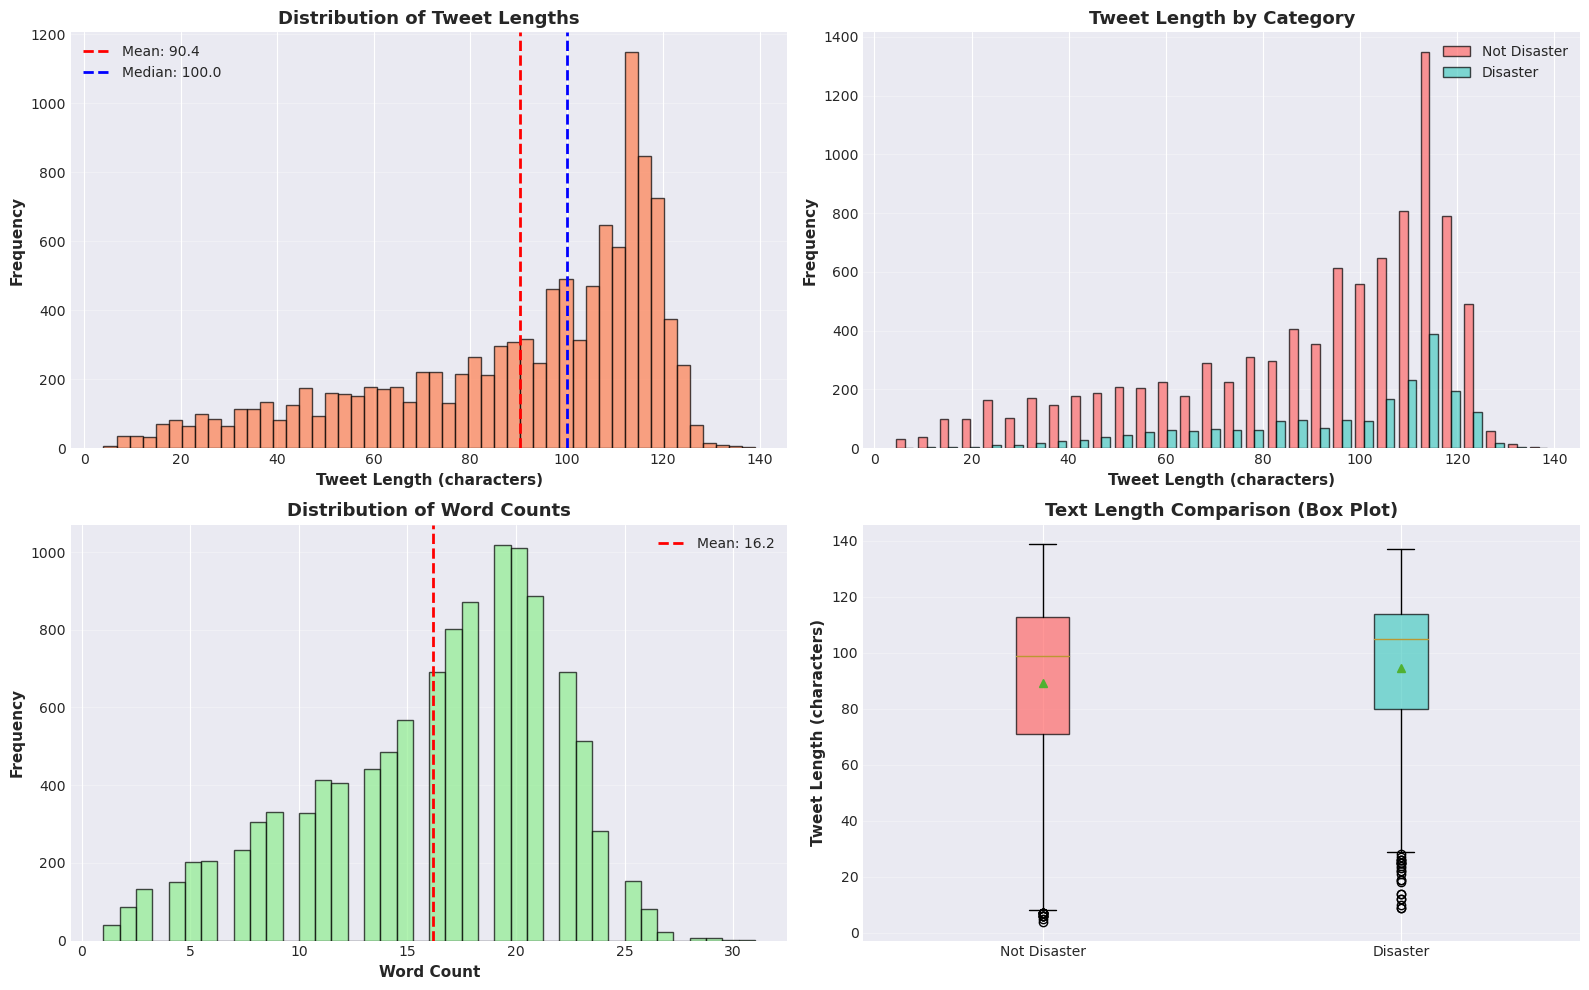

In [16]:
#  EDA - Visualizations Part 2 (Text Length Analysis)

# Figure 2: Text Length Distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Histogram of text lengths
axes[0, 0].hist(df['text_length'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['text_length'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {df["text_length"].mean():.1f}')
axes[0, 0].axvline(df['text_length'].median(), color='blue', linestyle='--', 
                   linewidth=2, label=f'Median: {df["text_length"].median():.1f}')
axes[0, 0].set_xlabel('Tweet Length (characters)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Distribution of Tweet Lengths', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Text length by target
disaster_lengths = df[df['target']==1]['text_length']
non_disaster_lengths = df[df['target']==0]['text_length']

axes[0, 1].hist([non_disaster_lengths, disaster_lengths], 
               bins=30, label=['Not Disaster', 'Disaster'],
               color=['#FF6B6B', '#4ECDC4'], alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Tweet Length (characters)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Tweet Length by Category', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Word count distribution
axes[1, 0].hist(df['word_count'], bins=40, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df['word_count'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {df["word_count"].mean():.1f}')
axes[1, 0].set_xlabel('Word Count', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Distribution of Word Counts', fontsize=13, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Box plot comparison
data_to_plot = [non_disaster_lengths, disaster_lengths]
bp = axes[1, 1].boxplot(data_to_plot, labels=['Not Disaster', 'Disaster'],
                        patch_artist=True, showmeans=True)
for patch, color in zip(bp['boxes'], ['#FF6B6B', '#4ECDC4']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 1].set_ylabel('Tweet Length (characters)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Text Length Comparison (Box Plot)', fontsize=13, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '2_text_length_analysis.png'), dpi=300, bbox_inches='tight')
print(f" Saved: 2_text_length_analysis.png")
plt.show()

\ Saved: 3_wordclouds.png


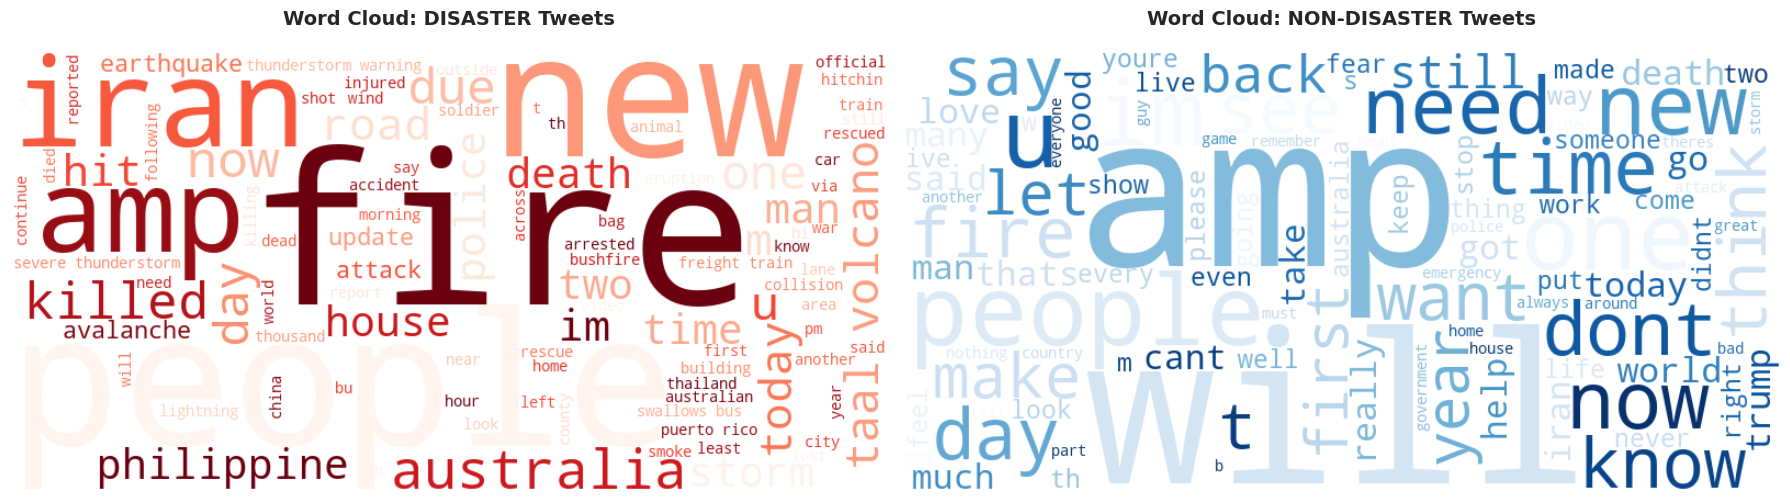


 All EDA visualizations complete!


In [17]:
# EDA - Word Clouds

# Figure 3: Word Clouds
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Disaster tweets word cloud
disaster_text = ' '.join(df[df['target']==1]['cleaned_text'])
wordcloud_disaster = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Reds',
    max_words=100,
    relative_scaling=0.5
).generate(disaster_text)

axes[0].imshow(wordcloud_disaster, interpolation='bilinear')
axes[0].set_title('Word Cloud: DISASTER Tweets', fontsize=14, fontweight='bold', pad=20)
axes[0].axis('off')

# Non-disaster tweets word cloud
non_disaster_text = ' '.join(df[df['target']==0]['cleaned_text'])
wordcloud_non_disaster = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Blues',
    max_words=100,
    relative_scaling=0.5
).generate(non_disaster_text)

axes[1].imshow(wordcloud_non_disaster, interpolation='bilinear')
axes[1].set_title('Word Cloud: NON-DISASTER Tweets', fontsize=14, fontweight='bold', pad=20)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '3_wordclouds.png'), dpi=300, bbox_inches='tight')
print(f"\ Saved: 3_wordclouds.png")
plt.show()

print("\n All EDA visualizations complete!")

In [19]:
#  Baseline Model - Feature Engineering
from sklearn.feature_extraction.text import TfidfVectorizer

print("="*70)
print("STEP 5: BASELINE MODEL TRAINING")
print("="*70)

print("\n Creating TF-IDF Features...")

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,           # Limit to top 5000 features
    ngram_range=(1, 2),          # Unigrams and bigrams
    min_df=2,                     # Minimum document frequency
    max_df=0.8,                   # Maximum document frequency
    strip_accents='unicode',
    lowercase=True
)

# Fit on training data and transform all sets
X_train = vectorizer.fit_transform(train['cleaned_text'])
X_val = vectorizer.transform(val['cleaned_text'])
X_test = vectorizer.transform(test['cleaned_text'])

# Get labels
y_train = train['target'].values
y_val = val['target'].values
y_test = test['target'].values

print(f"  TF-IDF Features Created!")
print(f"   Training set shape: {X_train.shape}")
print(f"   Validation set shape: {X_val.shape}")
print(f"   Test set shape: {X_test.shape}")
print(f"   Vocabulary size: {len(vectorizer.vocabulary_):,} unique tokens")

# Show top features
feature_names = vectorizer.get_feature_names_out()
print(f"\n Sample features (first 20):")
print(f"   {', '.join(feature_names[:20])}")

# Save vectorizer
with open(os.path.join(MODELS_DIR, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(vectorizer, f)
print(f"\n Vectorizer saved to: {MODELS_DIR}/tfidf_vectorizer.pkl")

STEP 5: BASELINE MODEL TRAINING

 Creating TF-IDF Features...
  TF-IDF Features Created!
   Training set shape: (8210, 5000)
   Validation set shape: (1449, 5000)
   Test set shape: (1705, 5000)
   Vocabulary size: 5,000 unique tokens

 Sample features (first 20):
   abandoned, ablaze, able, able to, about, about how, about it, about the, about this, about to, above, absolute, absolutely, abt, abu, abuse, academy, access, accident, accidentally

 Vectorizer saved to: /scratch/user/u.st336499/ML_Project/disaster_response_project/models/tfidf_vectorizer.pkl


In [20]:
#  Train Logistic Regression Baseline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, classification_report, confusion_matrix)
import time

print("\n Training Logistic Regression Model...")

start_time = time.time()

# Initialize model
model = LogisticRegression(
    max_iter=1000,
    multi_class='ovr',              # One-vs-Rest for binary
    solver='liblinear',             # Good for small datasets
    random_state=42,
    class_weight='balanced',        # Handle class imbalance
    C=1.0                           # Regularization strength
)

# Train
model.fit(X_train, y_train)

training_time = time.time() - start_time

print(f" Training Complete!")
print(f"   Training time: {training_time:.2f} seconds")

# Training accuracy
train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)
print(f"   Training accuracy: {train_acc:.4f}")

# Save model
with open(os.path.join(MODELS_DIR, 'baseline_model.pkl'), 'wb') as f:
    pickle.dump(model, f)
print(f"\n Model saved to: {MODELS_DIR}/baseline_model.pkl")


 Training Logistic Regression Model...
 Training Complete!
   Training time: 0.01 seconds
   Training accuracy: 0.9153

 Model saved to: /scratch/user/u.st336499/ML_Project/disaster_response_project/models/baseline_model.pkl


In [23]:
#  Comprehensive Model Evaluation

def evaluate_model(X, y, y_pred, dataset_name):
    """Comprehensive evaluation metrics"""
    
    # Calculate metrics
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average='binary')
    rec = recall_score(y, y_pred, average='binary')
    f1 = f1_score(y, y_pred, average='binary')
    cm = confusion_matrix(y, y_pred)
    
    print(f"{dataset_name.upper()} SET EVALUATION")
    
    print(f"\n Overall Metrics:")
    print(f"   Accuracy:  {acc:.4f}")
    print(f"   Precision: {prec:.4f}")
    print(f"   Recall:    {rec:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    
    print(f"\n Classification Report:")
    print(classification_report(y, y_pred, 
                                target_names=['Not Disaster', 'Disaster'],
                                digits=4))
    
    print(f"\n Confusion Matrix:")
    print(f"                 Predicted")
    print(f"                 Not    Disaster")
    print(f"   Actual Not    {cm[0,0]:5d}  {cm[0,1]:5d}")
    print(f"   Actual Dis    {cm[1,0]:5d}  {cm[1,1]:5d}")
    
    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'confusion_matrix': cm
    }

# Evaluate on all sets
print("\n EVALUATING MODEL ON ALL DATASETS...")

y_train_pred = model.predict(X_train)
train_metrics = evaluate_model(X_train, y_train, y_train_pred, "Training")

y_val_pred = model.predict(X_val)
val_metrics = evaluate_model(X_val, y_val, y_val_pred, "Validation")

y_test_pred = model.predict(X_test)
test_metrics = evaluate_model(X_test, y_test, y_test_pred, "Test")

print("\nBASELINE MODEL TRAINING COMPLETE!")



 EVALUATING MODEL ON ALL DATASETS...
TRAINING SET EVALUATION

 Overall Metrics:
   Accuracy:  0.9153
   Precision: 0.7127
   Recall:    0.9129
   F1-Score:  0.8005

 Classification Report:
              precision    recall  f1-score   support

Not Disaster     0.9787    0.9159    0.9463      6683
    Disaster     0.7127    0.9129    0.8005      1527

    accuracy                         0.9153      8210
   macro avg     0.8457    0.9144    0.8734      8210
weighted avg     0.9292    0.9153    0.9192      8210


 Confusion Matrix:
                 Predicted
                 Not    Disaster
   Actual Not     6121    562
   Actual Dis      133   1394
VALIDATION SET EVALUATION

 Overall Metrics:
   Accuracy:  0.8578
   Precision: 0.5899
   Recall:    0.7778
   F1-Score:  0.6709

 Classification Report:
              precision    recall  f1-score   support

Not Disaster     0.9451    0.8762    0.9093      1179
    Disaster     0.5899    0.7778    0.6709       270

    accuracy             

 
 Saved: 4_baseline_metrics_comparison.png


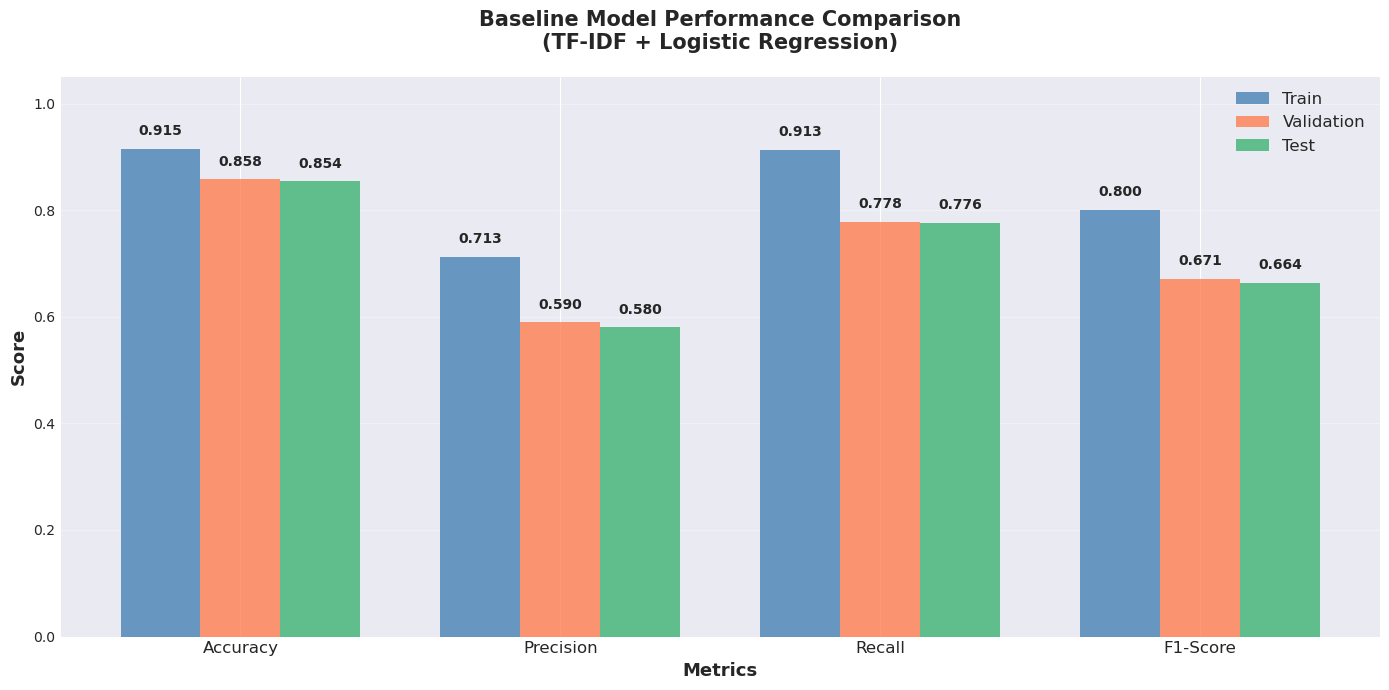

In [24]:
# Results Visualization

# Figure 4: Metrics Comparison
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
train_vals = [train_metrics['accuracy'], train_metrics['precision'], 
             train_metrics['recall'], train_metrics['f1_score']]
val_vals = [val_metrics['accuracy'], val_metrics['precision'], 
           val_metrics['recall'], val_metrics['f1_score']]
test_vals = [test_metrics['accuracy'], test_metrics['precision'], 
            test_metrics['recall'], test_metrics['f1_score']]

x = np.arange(len(metrics_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - width, train_vals, width, label='Train', alpha=0.8, color='steelblue')
bars2 = ax.bar(x, val_vals, width, label='Validation', alpha=0.8, color='coral')
bars3 = ax.bar(x + width, test_vals, width, label='Test', alpha=0.8, color='mediumseagreen')

ax.set_xlabel('Metrics', fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=13, fontweight='bold')
ax.set_title('Baseline Model Performance Comparison\n(TF-IDF + Logistic Regression)', 
            fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=12)
ax.legend(fontsize=12)
ax.set_ylim([0, 1.05])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (t, v, test) in enumerate(zip(train_vals, val_vals, test_vals)):
    ax.text(i - width, t + 0.02, f'{t:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.text(i + width, test + 0.02, f'{test:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '4_baseline_metrics_comparison.png'), 
           dpi=300, bbox_inches='tight')
print(f" \n Saved: 4_baseline_metrics_comparison.png")
plt.show()

 Saved: 5_confusion_matrices.png


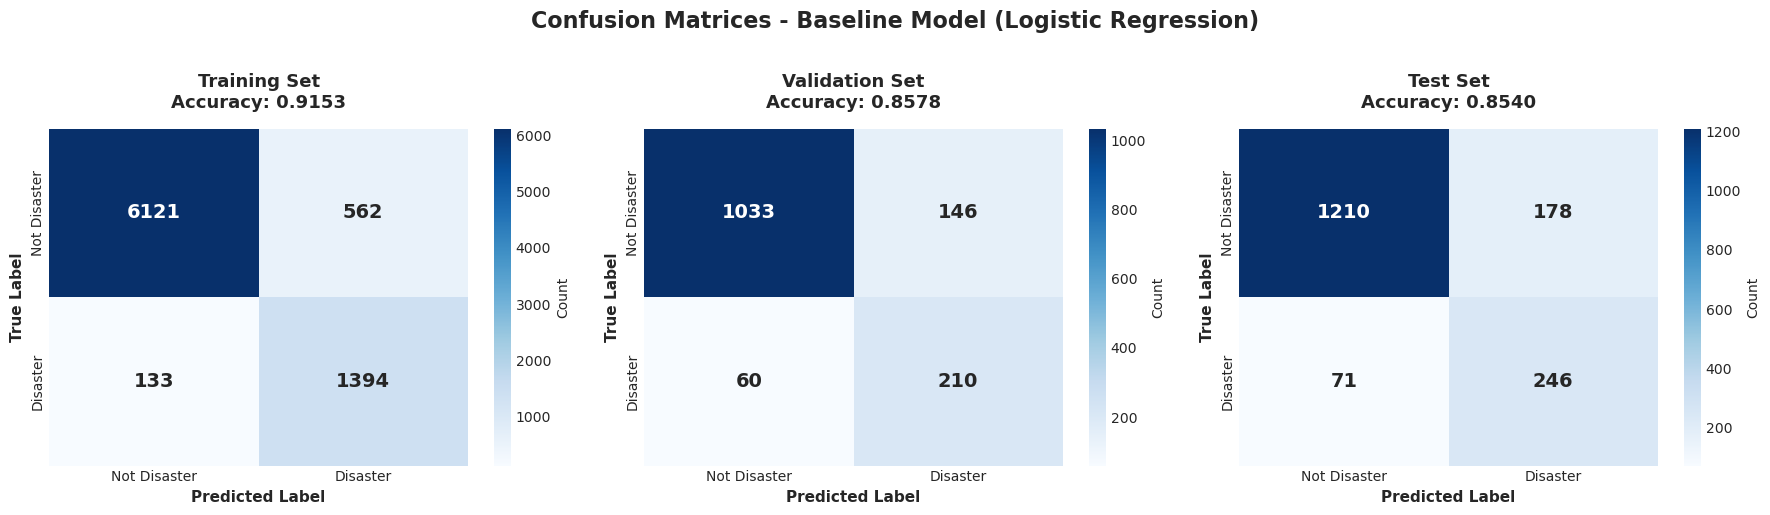


 All result visualizations complete!


In [26]:
#  Confusion Matrices Visualization

# Figure 5: Confusion Matrices for all sets
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    ('Training', train_metrics['confusion_matrix'], y_train, y_train_pred),
    ('Validation', val_metrics['confusion_matrix'], y_val, y_val_pred),
    ('Test', test_metrics['confusion_matrix'], y_test, y_test_pred)
]

for idx, (name, cm, y_true, y_pred) in enumerate(datasets):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
               xticklabels=['Not Disaster', 'Disaster'],
               yticklabels=['Not Disaster', 'Disaster'],
               cbar_kws={'label': 'Count'},
               ax=axes[idx],
               annot_kws={'size': 14, 'weight': 'bold'})
    
    axes[idx].set_title(f'{name} Set\nAccuracy: {accuracy_score(y_true, y_pred):.4f}', 
                       fontsize=13, fontweight='bold', pad=15)
    axes[idx].set_ylabel('True Label', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices - Baseline Model (Logistic Regression)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '5_confusion_matrices.png'), 
           dpi=300, bbox_inches='tight')
print(f" Saved: 5_confusion_matrices.png")
plt.show()

print("\n All result visualizations complete!")

In [31]:
#  Project Summary


print("PHASE 1 COMPLETE")


print(f"\nACCOMPLISHMENTS:")
print(f"   - Loaded {len(df):,} real disaster tweets")
print(f"   - Preprocessed and cleaned all text data")
print(f"   - Created train/val/test splits")
print(f"   - Performed comprehensive EDA")
print(f"   - Generated 5 visualizations")
print(f"   - Trained baseline TF-IDF + Logistic Regression model")
print(f"   - Achieved {test_metrics['accuracy']:.1%} test accuracy")
print(f"   - Achieved {test_metrics['f1_score']:.4f} F1-score")

print(f"\nFILES GENERATED:")
print(f"   Data: {DATA_PROCESSED}/")
print(f"   Models: {MODELS_DIR}/")
print(f"   Figures: {FIGURES_DIR}/")
print(f"   Reports: {REPORTS_DIR}/")

print(f"\nKEY METRICS:")
print(f"   Test Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"   Test Precision: {test_metrics['precision']:.4f}")
print(f"   Test Recall:    {test_metrics['recall']:.4f}")
print(f"   Test F1-Score:  {test_metrics['f1_score']:.4f}")

print(f"\nBASELINE ESTABLISHED")
print(f"This provides benchmark for deep learning models.")

print(f"\nREADY FOR:")
print(f"   - Intermediate Update 1 submission")
print(f"   - BERT implementation (Phase 2)")
print(f"   - Multi-task learning")
print(f"   - Final paper and presentation")


print("All results saved. Check your folders.")


# List all generated files
print("\nGENERATED FILES:")
import os
for root, dirs, files in os.walk(PROJECT_ROOT):
    level = root.replace(PROJECT_ROOT, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        if not file.startswith('.'):
            print(f'{subindent}{file}')

PHASE 1 COMPLETE

ACCOMPLISHMENTS:
   - Loaded 11,364 real disaster tweets
   - Preprocessed and cleaned all text data
   - Created train/val/test splits
   - Performed comprehensive EDA
   - Generated 5 visualizations
   - Trained baseline TF-IDF + Logistic Regression model
   - Achieved 85.4% test accuracy
   - Achieved 0.6640 F1-score

FILES GENERATED:
   Data: /scratch/user/u.st336499/ML_Project/disaster_response_project/data/processed/
   Models: /scratch/user/u.st336499/ML_Project/disaster_response_project/models/
   Figures: /scratch/user/u.st336499/ML_Project/disaster_response_project/figures/
   Reports: /scratch/user/u.st336499/ML_Project/disaster_response_project/reports/

KEY METRICS:
   Test Accuracy:  0.8540
   Test Precision: 0.5802
   Test Recall:    0.7760
   Test F1-Score:  0.6640

BASELINE ESTABLISHED
This provides benchmark for deep learning models.

READY FOR:
   - Intermediate Update 1 submission
   - BERT implementation (Phase 2)
   - Multi-task learning
   - Fin

In [2]:
cd 
zip -r ML_Project_backup.zip ML_Project/disaster_response_project/

SyntaxError: invalid syntax (1820855427.py, line 2)